# Custom Operator Experiment

The package lets a custom branch replace $L_\theta$ while preserving the
SILVA fixed-point structure:

$$
z^\star=\sigma\{S_\theta(x)+L_{\psi}(z^\star)+G_\theta(z^\star)\}.
$$

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [15](https://jseluis.github.io/silva-networks/paper/references/#ref-15), [16](https://jseluis.github.io/silva-networks/paper/references/#ref-16), [17](https://jseluis.github.io/silva-networks/paper/references/#ref-17), [18](https://jseluis.github.io/silva-networks/paper/references/#ref-18), [19](https://jseluis.github.io/silva-networks/paper/references/#ref-19), [20](https://jseluis.github.io/silva-networks/paper/references/#ref-20), [29](https://jseluis.github.io/silva-networks/paper/references/#ref-29). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
from silva_networks import SILVAGraphNetwork, SolverConfig

class SignedLocal(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.proj = torch.nn.Linear(dim, dim, bias=False)

    def forward(self, z, edge_index=None):
        messages = torch.tanh(self.proj(z))
        if edge_index is None:
            return messages
        src, dst = edge_index
        out = torch.zeros_like(messages)
        out.index_add_(0, dst, messages[src])
        return out

The custom module implements a local operator

$$
L_\psi:\mathbb R^{N\times d}\to\mathbb R^{N\times d}.
$$

The wrapper passes `edge_index` when it is available. The only hard contract is
that the returned tensor has the same shape as the recurrent state.

In [3]:
torch.manual_seed(4)
x = torch.randn(12, 6)
y = (x[:, 0] + 0.5 * x[:, 1] > 0).long()
edge_index = torch.tensor([list(range(11)), list(range(1, 12))], dtype=torch.long)

model = SILVAGraphNetwork(
    in_dim=6,
    hidden_dims=[16, 16],
    out_dim=2,
    task="node",
    local=lambda dim, index: SignedLocal(dim),
    global_term="mean",
    config=SolverConfig(solver="picard", max_iter=6, alpha=0.5),
)

Training does not need a special loop. The equilibrium layer is part of an
ordinary PyTorch module, so `loss.backward()` differentiates through the solver
steps used in the forward pass.

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
losses = []
for step in range(5):
    logits = model(x, edge_index=edge_index)
    loss = torch.nn.functional.cross_entropy(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))
    print(step, float(loss.detach()))

0 0.5560581684112549
1 0.4298062324523926
2 0.337056428194046
3 0.27874329686164856
4 0.21921612322330475


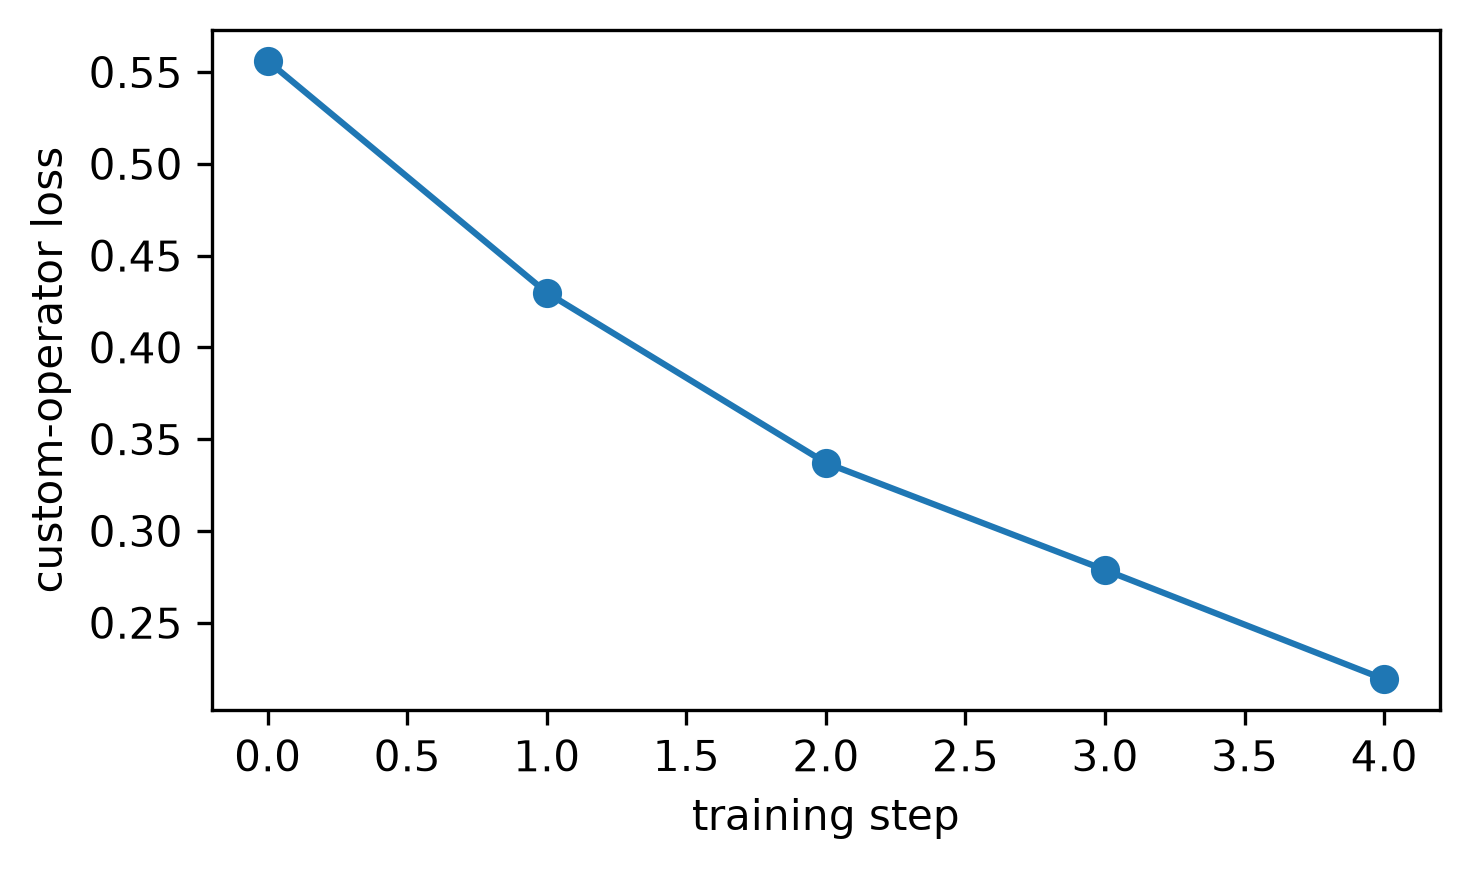

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

plt.figure(figsize=(5, 3))
plt.plot(losses, marker="o")
plt.xlabel("training step")
plt.ylabel("custom-operator loss")
plt.tight_layout()

## Citation and Sources

If this notebook or package is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.1.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA Networks paper, cite the paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background references used in the tutorial suite include:

- Deep Equilibrium Models, Bai, Kolter, and Koltun, NeurIPS 2019:
  https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models, Bai, Koltun, and Kolter, NeurIPS 2020:
  https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization, Bai, Koltun, and
  Kolter, ICML 2021: https://arxiv.org/abs/2106.14342
- Graph Attention Networks, Velickovic et al., ICLR 2018:
  https://arxiv.org/abs/1710.10903
- Attention Is All You Need, Vaswani et al., 2017:
  https://arxiv.org/abs/1706.03762

## From 05 Custom Operator Experiment to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [6]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [7]:
notebook_reproduction_record = {
    "notebook": '05_custom_operator_experiment.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '05_custom_operator_experiment.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Where to Go Next

| Question | Page |
| --- | --- |
| How are custom branches derived and validated? | [Custom Layers](https://jseluis.github.io/silva-networks/learn/custom-layers/) |
| Where is a smaller custom-layer script? | [Custom Layers Example](https://jseluis.github.io/silva-networks/examples/custom-layers/) |
| Which layer contracts must the operator preserve? | [Layers API](https://jseluis.github.io/silva-networks/api/layers/) |
